# Домашнее задание №4: Image Captioning с Transformers

## Описание задачи

В этом задании вы будете обучать игрушечную модель **Image Captioning** для распознавания чисел с изображений.

**Задача:** По изображению с рукописным числом модель должна сгенерировать текстовое описание на русском языке.

**Примеры:**
- Изображение: `242` → Модель: `"<bos>двести сорок два<eos>"`
- Изображение: `1337` → Модель: `"<bos>одна тысяча триста тридцать семь<eos>"`

**Архитектура:**
- **Vision Encoder:** MobileNetV3 + Transformer Encoder (извлекает визуальные признаки)
- **Generative Decoder:** Transformer Decoder с causal masking (генерирует текст autoregressive)
- **Positional Encoding:** RoPE (Rotary Position Embeddings)

**Токенизатор:** Примитивный посимвольный (1 буква = 1 токен), алфавит содержит русские буквы + спецсимволы.

**Файлы:**
- `train.csv`, `test.csv` — разметка (путь к изображению + текст)
- `images.zip` — директория с изображениями чисел, https://disk.yandex.ru/d/OQzUybF0h-ld0w
- `checkpoint_from_authors.pth` — предобученный checkpoint (приемлемого качества, но специально далеко не идеальный и галлюцинирующий, пригодится для отладки)

---

## Система оценивания

**В шкалу 0-1 переведем делением на 10, то есть можно получить больше единицы за все задание**

| Задание | Баллы |
|---------|-------|
| **Задание 1:** Валидация, метрики CER и Exact Accuracy | 2 |
| **Задание 2:** Простой inference (`run_inference_simple`) | 2 |
| **Задание 3:** Early stopping + `torch.compile` | 2 |
| **Задание 4:** Inference с KV-cache (`run_inference_kv_cache`) | 6 |
---


In [4]:
!unzip images.zip

Выходные данные были обрезаны до нескольких последних строк (5000).
 extracting: images/95/04.jpg        
 extracting: images/95/05.jpg        
 extracting: images/95/06.jpg        
 extracting: images/95/07.jpg        
 extracting: images/95/08.jpg        
 extracting: images/95/09.jpg        
 extracting: images/95/10.jpg        
 extracting: images/95/100.jpg       
 extracting: images/95/101.jpg       
 extracting: images/95/102.jpg       
 extracting: images/95/103.jpg       
 extracting: images/95/104.jpg       
 extracting: images/95/105.jpg       
 extracting: images/95/106.jpg       
 extracting: images/95/107.jpg       
 extracting: images/95/108.jpg       
 extracting: images/95/109.jpg       
 extracting: images/95/11.jpg        
 extracting: images/95/110.jpg       
 extracting: images/95/111.jpg       
 extracting: images/95/112.jpg       
 extracting: images/95/113.jpg       
 extracting: images/95/114.jpg       
 extracting: images/95/115.jpg       
 extracting: images/

In [1]:
import os
import sys
import typing as tp
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import pandas as pd
import random
import matplotlib.pyplot as plt
import albumentations as A
import imageio
import tqdm
import cv2
from collections import defaultdict
from IPython import display

from pathlib import Path

In [2]:
if not torch.cuda.is_available():
    raise RuntimeError('Please, use cuda or xla environment')

# не знаю, почему тут индекс 1, у меня в коллабе под индексом 0
# device = torch.device('cuda:1')
device = torch.device('cuda:0')

In [3]:
torch.cuda.get_device_name(0)

'Tesla T4'

## Посмотрим на данные и задачу:

,Unnamed: 0,image,text
6881,7433,07/433.jpg,пятьсот пятьдесят восемь
15804,68817,68/817.jpg,четыреста восемнадцать
12638,56672,56/672.jpg,триста восемьдесят один
17800,51983,51/983.jpg,девятьсот семьдесят один
8214,97216,97/216.jpg,семьсот девяносто пять


/tmp/ipykernel_303/1063636248.py:8: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread('images/' + line['image'])


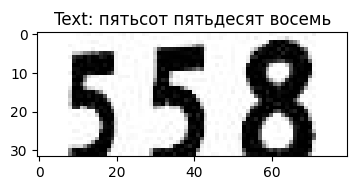

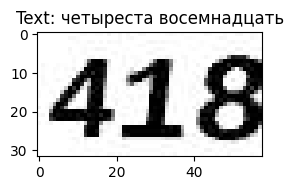

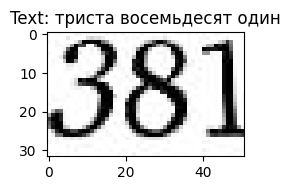

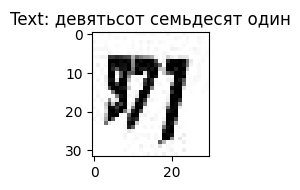

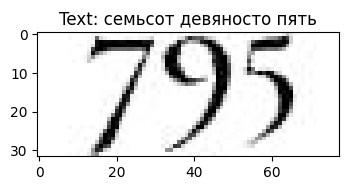

In [5]:
df = pd.read_csv('test.csv')
sample = df.sample(5)

display.display(sample)

for i in range(len(sample)):
    line = sample.iloc[i]
    image = imageio.imread('images/' + line['image'])
    text = line['text']

    plt.figure(figsize=(5, 2))
    plt.title(f'Text: {text}')
    plt.tight_layout()
    plt.imshow(image, cmap='Greys', vmin=0, vmax=255)
    plt.show()


Вот это вообще сильно.

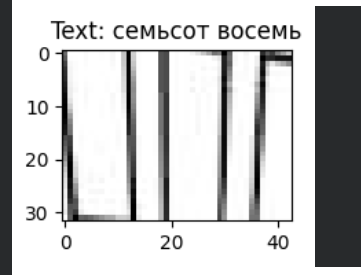

In [6]:
ALPHABET = list('абвгдежзийклмнопрстуфхцчшщъыьэюя ')
# Максимальная генерируемая длина выхода
MAX_TARGET_SIZE = 33 # 2^N + 1, догадайтесь, кстати, почему +1
# неверое по тому, что bos уже есть, а остальные 32 генерим
BATCH_SIZE = 1024
# NUM_WORKERS = 4
# Коллаб попросил поменять
NUM_WORKERS = 2
HIDDEN_SIZE = 64

class SimpleCaptioningDataset(torch.utils.data.Dataset):
    def __init__(self, csv_path: str | Path, alphabet: tp.List[str], max_target_size: int, valid: bool = False) -> None:
        super().__init__()

        if isinstance(csv_path, str):
            csv_path = Path(csv_path)

        self._csv_path = csv_path
        self._alphabet = ['<pad>', '<bos>', '<eos>', '<unk>'] + alphabet
        self._max_target_size = max_target_size

        self._bos = '<bos>'
        self._bos_id = 1
        self._eos = '<eos>'
        self._eos_id = 2
        self._pad = '<pad>'
        self._pad_id = 0
        self._unk = '<unk>'
        self._unk_id = 3

        self._tok_to_id = {item: index for index, item in enumerate(self._alphabet)}


        self._markup = pd.read_csv(self._csv_path)
        self._markup_folder = self._csv_path.parent

        # Высота всех картинок в датасете - 32px, ширина - произвольная.
        # Здесь реализовано приведение к фиксированной ширине, вам же нужно будет в дополнительной части
        # перепроектировать для работы в режиме navit
        self._augmentations = [] if valid else [
            A.ElasticTransform(p=0.2),
            A.GridDistortion(p=0.2),
            A.Perspective(p=0.2),
            A.RandomBrightnessContrast(p=0.3),
            A.RandomGamma(p=0.3),
            A.Affine(p=0.3),
        ]
        self._preprocessor = A.Compose(
            self._augmentations +
            [
                A.Resize(
                    height=32,
                    width=256,
                ),
                A.Normalize(
                    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], max_pixel_value=255.0, p=1.0
                ),
                A.pytorch.ToTensorV2(),
            ]
        )

    def __len__(self) -> int:
        return len(self._markup)

    def _prepare_text(self, text: str) -> torch.Tensor:
        text = [self._bos] + list(text) + [self._eos]
        text = text[:self._max_target_size]
        text += [self._pad] * (self._max_target_size - len(text))
        token_ids = torch.Tensor([self._tok_to_id.get(tok, self._unk_id) for tok in text]).type(torch.int64)
        return token_ids

    def _text_with_shift(self, token_ids: torch.Tensor) -> tp.Tuple[torch.Tensor, torch.Tensor]:
        return token_ids[:-1], token_ids[1:]


    def __getitem__(self, index: int) -> tp.Tuple[tp.Tuple[torch.Tensor, torch.Tensor], torch.Tensor]:
        item = self._markup.iloc[index]
        image = cv2.imread(self._markup_folder / 'images' / item['image'], cv2.IMREAD_COLOR_RGB)
        image = self._preprocessor(image=image)['image']

        text = self._prepare_text(item['text'])

        text_in, text_out = self._text_with_shift(text)

        return (image, text_in), text_out




ds_train = SimpleCaptioningDataset(csv_path='train.csv', alphabet=ALPHABET, max_target_size=MAX_TARGET_SIZE)
ds_test = SimpleCaptioningDataset(csv_path='test.csv', alphabet=ALPHABET, max_target_size=MAX_TARGET_SIZE, valid=True)

loader_train = torch.utils.data.DataLoader(ds_train, batch_size=BATCH_SIZE, pin_memory=True, prefetch_factor=2, num_workers=NUM_WORKERS, shuffle=True, drop_last=True)
loader_test = torch.utils.data.DataLoader(ds_test, batch_size=BATCH_SIZE, pin_memory=True, prefetch_factor=2, num_workers=NUM_WORKERS, shuffle=True, drop_last=True)


In [7]:
class RotaryEmbedding(nn.Module):
    def __init__(self, d: int, max_wavelength: float = MAX_TARGET_SIZE * 4):
        super().__init__()
        inv_freq = 1.0 / (max_wavelength ** (torch.arange(0, d, 2).float() / d))
        self.register_buffer("inv_freq", inv_freq)

    def forward(
        self,
        x: torch.Tensor,
        start_index: tp.Union[int, torch.Tensor] = 0
    ) -> torch.Tensor:
        # x: (bs, seq_len, d)
        bs, seq_len, d = x.shape
        device = x.device

        if isinstance(start_index, int):
            pos = torch.arange(seq_len, device=device).unsqueeze(0) + start_index
        else:
            start_index = start_index.to(device).view(bs, 1)
            pos = torch.arange(seq_len, device=device).unsqueeze(0) + start_index

        # 2. Считаем углы freqs: (bs, seq_len, d//2)
        # einsum перемножает pos (bs, seq_len) и inv_freq (d//2)
        freqs = torch.einsum("bs,f->bsf", pos.float(), self.inv_freq)
        emb = torch.repeat_interleave(freqs, 2, dim=-1)
        cos, sin = emb.cos(), emb.sin()

        # 4. Поворачиваем x (interleaved: меняем местами соседние элементы и инвертируем знак четных)
        # Пример: [x0, x1, x2, x3] -> [-x1, x0, -x3, x2]
        x_rotated = torch.stack([-x[..., 1::2], x[..., 0::2]], dim=-1).reshape(bs, seq_len, d)

        # 5. Применяем RoPE
        return (x * cos) + (x_rotated * sin)


class VisionModel(nn.Module):
    def __init__(self) -> None:
        super().__init__()

        self._backbone = torchvision.models.mobilenet_v3_small(weights='IMAGENET1K_V1')
        self._channels_downsampler = nn.Conv2d(kernel_size=(1, 1), in_channels=576, out_channels=HIDDEN_SIZE)

        self._single_encoder_layer = nn.TransformerEncoderLayer(d_model=HIDDEN_SIZE, nhead=4, dropout=0.1, batch_first=True)
        self._transformer_encoder = nn.TransformerEncoder(self._single_encoder_layer, num_layers=3)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: bs, 3, h, w
        x = self._backbone.features(x)
        # x: bs, 576, h // 32, w // 32
        x = self._channels_downsampler(x)
        # x: bs, 128, h // 32, w // 32
        x = x.reshape(-1, x.shape[1], x.shape[2] * x.shape[3]).permute(0, 2, 1)
        # x: bs, h // 32 * w // 32, 128
        # h // 32 * w // 32 = 8 по дефолту, каждая картинка = 8 токенов, всегда
        x = self._transformer_encoder(x)
        # x: bs, h // 32 * w // 32, 128
        return x


class GenerativeModel(nn.Module):
    def __init__(self) -> None:
        super().__init__()

        self._single_decoder_layer = nn.TransformerDecoderLayer(d_model=HIDDEN_SIZE, nhead=4, dropout=0.1, batch_first=True)
        self._transformer_decoder = nn.TransformerDecoder(self._single_decoder_layer, num_layers=3)

    def forward(self, seq: torch.Tensor, memory: torch.Tensor) -> torch.Tensor:
        tgt_mask = torch.nn.Transformer.generate_square_subsequent_mask(device=seq.device, sz=seq.shape[1])
        return self._transformer_decoder(tgt=seq, memory=memory, tgt_mask=tgt_mask[None, :, :], tgt_is_causal=True)


class CaptioningModel(nn.Module):
    def __init__(self, n_classes: int) -> None:
        super().__init__()

        self._n_classes = n_classes
        self._vision_model = VisionModel()
        self._generative_model = GenerativeModel()

        self._rotary = RotaryEmbedding(d=HIDDEN_SIZE)

        self._embeddings = nn.Embedding(num_embeddings=n_classes, embedding_dim=HIDDEN_SIZE // 4)
        self._in_linear = nn.Linear(in_features=HIDDEN_SIZE // 4, out_features=HIDDEN_SIZE)
        self._out_linear = nn.Linear(in_features=HIDDEN_SIZE, out_features=self._n_classes)

    def forward(self, seq: torch.Tensor, image: torch.Tensor, start_index: tp.Union[int, torch.Tensor] = 0) -> torch.Tensor:
        image_embeds = self._vision_model(image)
        image_embeds = self._rotary(image_embeds, start_index=0)

        seq = self._embeddings(seq)
        seq = self._in_linear(seq)
        seq = self._rotary(seq, start_index=start_index)

        seq = self._generative_model(seq, memory=image_embeds)
        seq = self._out_linear(seq)

        return seq

vision_model = VisionModel()
print(vision_model(torch.randn(1, 3, 32, 256)).shape)

generative_model = GenerativeModel()
print(generative_model(torch.randn(3, 2, HIDDEN_SIZE), torch.randn(3, 7, HIDDEN_SIZE)).shape)

captioning_model = CaptioningModel(n_classes=len(ALPHABET) + 8)
print(captioning_model(torch.zeros(3, 2, dtype=torch.long), torch.randn(3, 3, 32, 256)).shape)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 184MB/s]


torch.Size([1, 8, 64])
torch.Size([3, 2, 64])
torch.Size([3, 2, 41])


In [8]:
checkpoints_path = Path('checkpoints')
checkpoints_path.mkdir(exist_ok=True, parents=True)

In [9]:
class MaskedCrossEntropyLoss(nn.Module):
    def __init__(self, **kwargs: tp.Any) -> None:
        super().__init__()
        self._internal = nn.CrossEntropyLoss(**kwargs)

    def forward(self, pred: torch.Tensor, tgt: torch.Tensor) -> torch.Tensor:
        loss_values = self._internal(pred.permute(0, 2, 1), tgt)
        loss_mask = torch.where(tgt > 0, torch.ones_like(tgt), torch.zeros_like(tgt)).type(loss_values.dtype)
        loss_values *= loss_mask
        loss_value = loss_values.sum() / (loss_mask.sum() + 1e-4)
        return loss_value

# Train loop

---

## Задание 1: Валидация и метрики (2 балла)

### Что нужно сделать

Дополните цикл обучения и дообучите модель (нужно типа 30 эпох и лосс как минимум около 0.75):

1. **Добавьте валидацию:** После каждой эпохи обучения запустите проход по `loader_test` без градиентов
2. **Подсчитайте loss на валидации:** Используйте тот же `MaskedCrossEntropyLoss`
3. **Реализуйте метрики:**
   - **CER (Character Error Rate)** — процент ошибочных символов
   - **Exact Accuracy** — процент полностью правильных предсказаний

### Метрики: теория

#### Character Error Rate (CER)

CER измеряет **долю ошибок** на уровне символов, используя **расстояние Левенштейна** (edit distance):

$$
\text{CER} = \frac{\text{Insertions} + \text{Deletions} + \text{Substitutions}}{\text{Length of reference}} \times 100\%
$$

---

**Пример:**

* Reference: "двести сорок два"
* Hypothesis: "двесте сорак два"

---

* Total errors: 2
* Reference length: 17

CER = 2/17 ≈ 11.8%


#### Exact Match Accuracy

Exact Accuracy — **строгая метрика**: предсказание считается правильным **только** если полностью совпадает с ground truth:

$$
\text{Exact Acc} = \frac{\text{Number of exact matches}}{\text{Total samples}} \times 100\%
$$

---

**Пример:**

* Reference: "двести сорок два"
* Hypothesis: "двести сорок два" ✓ Exact match (Exact Acc += 1)

---

* Reference: "триста пять"
* Hypothesis: "триста пят" ✗ Not exact match (CER = 20%, но Exact Acc += 0)

### Что логировать

Выводите после каждой эпохи:
```
Epoch 001 | train_loss: 2.1234 | val_loss: 2.4567 | val_cer: 15.23% | val_exact_acc: 42.50%
```


In [31]:
torch.cuda.empty_cache()

loss = MaskedCrossEntropyLoss(label_smoothing=0.1, ignore_index=0, reduction='none') # ignore_index = index of '<pad>'!!!!
model = CaptioningModel(n_classes=len(ALPHABET) + 8)
model.to(device)

# с torch compile не учится ни локально (так как винда), на коллабе только хуже от этого
# @torch.compile
def train_step(model, optimizer, loss, data) -> tp.Dict[str, torch.Tensor]:
    (image, src), tgt = data
    image = image.to(device)
    src = src.to(device)
    tgt = tgt.to(device)

    optimizer.zero_grad()

    pred = model(src, image)
    loss_value = loss(pred, tgt)
    loss_value.backward()

    optimizer.step()

    return {
        'loss': loss_value.item()
    }


In [11]:
import editdistance

def batch_cer(pred_tokens, tgt_tokens, pad_id=0):
    total_dist = 0
    total_chars = 0

    pred_tokens = pred_tokens.cpu().numpy()
    tgt_tokens = tgt_tokens.cpu().numpy()

    for p, t in zip(pred_tokens, tgt_tokens):
        p = [x for x in p if x != pad_id]
        t = [x for x in t if x != pad_id]

        total_dist += editdistance.eval(p, t)
        total_chars += len(t)

    return total_dist, total_chars

def exact_match(pred, tgt, eos_id=ds_test._eos_id):
    bs, seq_len = tgt.shape
    correct = 0

    for i in range(bs):
        t = tgt[i]
        p = pred[i]

        # позиция EOS в target
        eos_pos = (t == eos_id).nonzero(as_tuple=True)[0]
        if len(eos_pos) > 0:
            end = eos_pos[0].item()
        else:
            end = seq_len

        if torch.equal(p[:end], t[:end]):
            correct += 1

    return correct

@torch.no_grad()
def validation(model, loss, loader):
  model.eval()
  total_loss = 0.0
  total_right_pred = 0
  total_samples = 0
  total_edit_dist = 0
  total_chars = 0

  for (image, src), tgt in tqdm.tqdm(loader, desc="validation"):
    image = image.to(device)
    src = src.to(device)
    tgt = tgt.to(device)

    pred = model(src, image)

    loss_value = loss(pred, tgt)
    total_loss += loss_value.item()

    pred_tokens = pred.argmax(dim=2)
    # так считать не корректно, так как модель генерит не только pad после eos
    # exact = (pred_tokens == tgt).all(dim=1)
    # total_right_pred += exact.sum().item()

    total_right_pred += exact_match(pred_tokens, tgt)

    dist, chars = batch_cer(pred_tokens, tgt, pad_id=ds_test._pad_id)
    total_edit_dist += dist
    total_chars += chars

    total_samples += tgt.shape[0]

  return {
        'loss': total_loss / len(loader),
        'cer': total_edit_dist / total_chars * 100,
        'exact_acc': total_right_pred / (total_samples) * 100
    }

У меня постоянно выскакивает этот AssertionError, потратил уже несколько часов, чтоб понять, как его пофиксить в collab. Достало. Видимо с num_workers > 0 без шансов. Так что, для читаемости буду чистить вывод ячейки и рисовать графки.

In [12]:
import sys
sys.tracebacklimit = 0 # gpt посоветовал, чтоб убрать AssertionError, вроде помогло

In [13]:
from IPython.display import clear_output
def plot_progress(train_losses, val_losses, val_cer, val_exact_acc):
    clear_output()
    fig, axs = plt.subplots(1, 3, figsize=(18, 4))
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label='train')
    axs[0].plot(range(1, len(val_losses) + 1), val_losses, label='val')
    axs[0].set_ylabel('loss')

    axs[1].plot(range(1, len(val_cer) + 1), val_cer, label='score')
    axs[1].set_ylabel('cer')

    axs[2].plot(range(1, len(val_cer) + 1), val_exact_acc, label='score')
    axs[2].set_ylabel('exact accuracy')

    for ax in axs:
        ax.set_xlabel('epoch')
        ax.legend()

    plt.show()

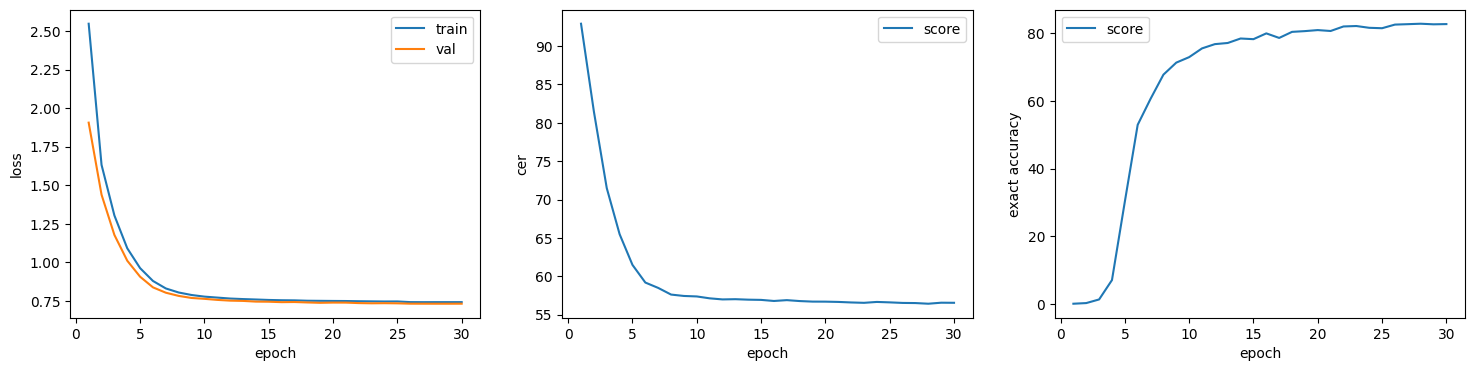

Epoch 29 | train_loss: 0.7423 | val_loss: 0.7322 | val_cer: 56.5424 %| val_exact_acc: 82.6172 %| 


In [14]:
NUM_EPOCHS = 30

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=25, gamma=0.2)

train_losses = []
test_losses = []
test_cer = []
test_exact_acc = []

for epoch in range(NUM_EPOCHS):
    metrics = defaultdict(list)
    for data in tqdm.tqdm(loader_train, desc=f"epoch {epoch}"):
        optimizer.zero_grad()

        step_values = train_step(model, optimizer, loss, data)

        for k, v in step_values.items():
            metrics[f"train_{k}"].append(v)

    valid_values = validation(model, loss, loader_test)

    train_losses.append(np.mean(metrics["train_loss"]))
    test_losses.append(valid_values["loss"])
    test_cer.append(valid_values["cer"])
    test_exact_acc.append(valid_values["exact_acc"])

    for k, v in valid_values.items():
      metrics[f"val_{k}"].append(v)

    log = f'Epoch {epoch} | '
    for k, v in metrics.items():
        avg = sum(v) / len(v)
        extra_symbol = ""
        if (len(k) >= 3 and k[-3:] == 'cer') or (len(k) >= 9 and k[-9:] == 'exact_acc'):
          extra_symbol = "%"

        log += f'{k}: {avg:.04f} {extra_symbol}| '


    plot_progress(train_losses, test_losses, test_cer, test_exact_acc)
    print(log)

    scheduler.step()

    torch.save(model.state_dict(), checkpoints_path / 'last.pth')

Интересно, что на валидации меньше лосс. Это скорее всего по тому, что на обучение dropout мешает.

In [15]:
sys.tracebacklimit = None # вернём ошибки и warning-и


## Задание 2: Простой inference (2 балла)

### Что нужно сделать

Реализуйте функцию `run_inference_simple`, которая:

**Вход:**
- `model` — обученная модель `CaptioningModel`
- `images` — батч изображений `torch.Tensor` размера `[batch_size, 3, 32, 256]` (уже нормализованные)

**Выход:**
- `List[str]` — список строк-описаний для каждого изображения, начинающихся с `<bos>` и заканчивающихся на `<eos>`

**Пример:**
```python
images = torch.randn(4, 3, 32, 256).to(device)
captions = run_inference_simple(model, images)

# captions = [
#     "<bos>двести сорок два<eos>",
#     "<bos>сто одиннадцать<eos>",
#     "<bos>триста пятьдесят<eos>",
#     "<bos>семьдесят семь<eos>"
# ]

```

1. **Энкодинг изображений:**
   ```python
   image_embeds = model.vision_model(images)  # [batch, seq_len, hidden_dim]
   image_embeds = model.rotary(image_embeds, start_index=0)
   ```

2. **Инициализация:** Начинаем с токена `<bos>` (id=1):
   ```python
   seq = ...  # [batch, 1]
   ```

3. **Autoregressive цикл:** На каждом шаге:
   - Эмбеддинг текущей последовательности
   - Применяем RoPE
   - Пропускаем через decoder
   - Берем логиты последнего токена
   - Выбираем токен с максимальной вероятностью (`argmax`)
   - Добавляем его к последовательности

4. **Остановка:** Генерируем до `MAX_TARGET_SIZE` токенов

5. **Декодирование:** Преобразуем `token_ids` обратно в строки через `dataset._alphabet`


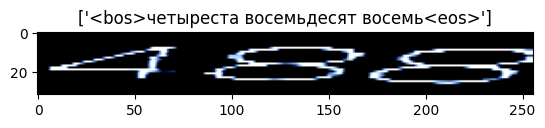

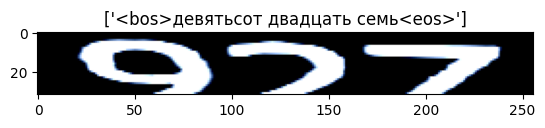

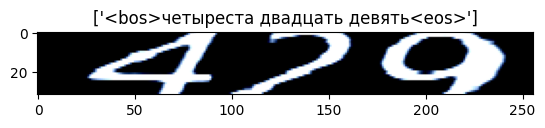

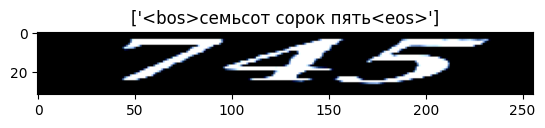

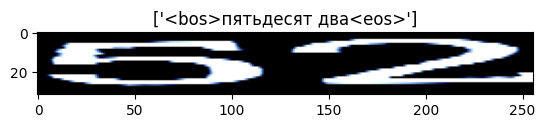

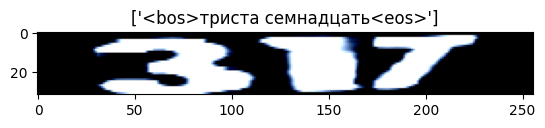

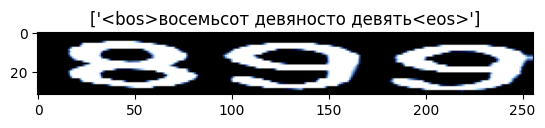

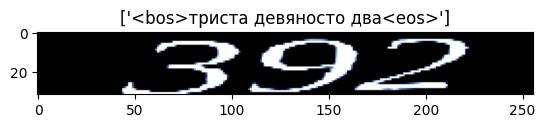

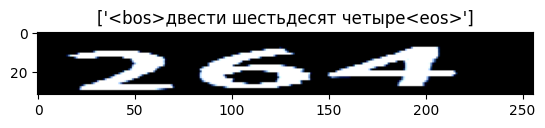

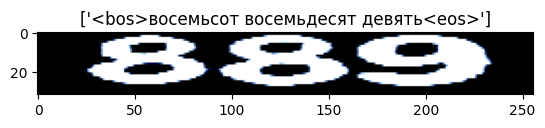

In [17]:
@torch.inference_mode()
def run_inference_simple(model: CaptioningModel, images: torch.Tensor) -> tp.List[str]:
    """
    Простой autoregressive inference без оптимизаций

    Args:
        model: обученная модель CaptioningModel
        images: батч изображений [batch_size, 3, 32, 256] (уже нормализованные, как на выходе из датасета)

    Returns:
        captions: список строк-описаний для каждого изображения
                  Формат: "<bos>текст<eos>"
    """
    model.eval()

    bos_id = ds_test._bos_id
    eos_id = ds_test._eos_id
    id_to_tok = ds_test._alphabet

    batch_size = images.shape[0]

    # начинаем с <bos>
    seq = torch.full(
        (batch_size, 1),
        bos_id,
        dtype=torch.long,
        device=device
    )

    image_embeds = model._vision_model(images)
    image_embeds = model._rotary(image_embeds, start_index=0)

    finished = torch.zeros(batch_size, dtype=torch.bool, device=device)

    for _ in range(MAX_TARGET_SIZE - 1):
        x = seq
        x = model._embeddings(x)
        x = model._in_linear(x)
        x = model._rotary(x, start_index=0)

        x = model._generative_model(x, memory=image_embeds)
        logits = model._out_linear(x)

        # нам нужен только последний предсказанный токен
        next_token = logits[:, -1].argmax(-1, keepdim=True)

        seq = torch.cat([seq, next_token], dim=1)

        finished |= (next_token.squeeze(-1) == eos_id)

        if finished.all():
            break

    # переводим в текст
    captions = []

    seq = seq.cpu().numpy()

    for tokens in seq:
        text = []
        for t in tokens:
            text.append(id_to_tok[t])
            if t == eos_id:
                break

        captions.append("".join(text))

    return captions


for i in range(10):
    index = random.randint(0, len(ds_test))
    (image, _), _ = ds_train[index]

    result = run_inference_simple(model, image[None, :, :, :].to(device))

    plt.title(result)
    plt.imshow(image.cpu().detach().numpy().transpose(1, 2, 0))
    plt.show()




## Задание 3: Early stopping + torch.compile (1 балл)

### Что нужно сделать

Улучшите `run_inference_simple` двумя способами:

1. **Early stopping генерации:**
   - Останавливайте цикл, когда **все** элементы батча сгенерировали `<eos>` (id=2)
   - Избегайте бесполезных вычислений после завершения генерации

2. **Оберните в `torch.compile` и проверьте, что это еще лучше ускоряет инференс (лучше на большой батче брать среднее время по нескольким прогонам):**
   - Декорируйте функцию inference через `@torch.compile`
   - Или примените явно: `run_inference_compiled = torch.compile(run_inference_simple)`

### Пример early stopping

```python
# Трекаем, какие элементы батча уже закончили генерацию
finished = torch.zeros(batch_size, dtype=torch.bool, device=device)

for step in range(max_length):
    # ... генерация нового токена ...
    
    # Проверяем, кто сгенерировал <eos>
    finished |= (next_token == eos_id)
    
    # Если все закончили - выходим
    if finished.all():
        break
```


Early stopping я уже реализовал, compile очень долго запускается в коллабе, по крайней мере на обучении, и из за этого не даёт выигрыша. Да он в целом и не ускорял обучение почему то. Но я попробую с ним и без него.

Буду делать замеры скорости на всех вариантах  инференса.

In [18]:
import time

def benchmark_inference(model, images, inference_fn, n_runs=10):
    model.eval()

    # cuda работает ассинхронно,
    # заставляем её дождаться завершения всех процессов на GPU
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    images = images.to(device)
    times = []

    with torch.no_grad():
        for _ in tqdm.tqdm(range(n_runs), desc="inference runtime"):

            start = time.perf_counter()

            inference_fn(model, images)

            if torch.cuda.is_available():
                torch.cuda.synchronize()

            end = time.perf_counter()

            times.append(end - start)

    avg_time = sum(times) / len(times)

    print(f"\nAverage inference time: {avg_time:.4f} sec")

    return avg_time

Первый вариант, уже с early stopping, но ещё с  генерацией после eos  если какое то  из предложений не выдало eos.

In [19]:
(batch_images, _), _ = next(iter(loader_test))
print(f"Размер батча: {batch_images.shape[0]}")

benchmark_inference(model, batch_images, run_inference_simple, n_runs=10)
None

Размер батча: 1024


inference runtime: 100%|██████████| 10/10 [00:07<00:00,  1.42it/s]


Average inference time: 0.7046 sec


In [20]:
@torch.inference_mode()
def run_inference(model: CaptioningModel, images: torch.Tensor) -> tp.List[str]:
    """
    Простой autoregressive inference без оптимизаций

    Args:
        model: обученная модель CaptioningModel
        images: батч изображений [batch_size, 3, 32, 256] (уже нормализованные, как на выходе из датасета)

    Returns:
        captions: список строк-описаний для каждого изображения
                  Формат: "<bos>текст<eos>"
    """
    model.eval()

    bos_id = ds_test._bos_id
    eos_id = ds_test._eos_id
    id_to_tok = ds_test._alphabet

    batch_size = images.shape[0]

    # начинаем с <bos>
    seq = torch.full(
        (batch_size, 1),
        bos_id,
        dtype=torch.long,
        device=device
    )

    image_embeds = model._vision_model(images)
    image_embeds = model._rotary(image_embeds, start_index=0)

    # буду трекать, какие еще не выдали eos, и только их гнать через трансформер
    alive = torch.arange(batch_size, device=device)

    for _ in range(MAX_TARGET_SIZE - 1):
        x = seq[alive]
        x = model._embeddings(x)
        x = model._in_linear(x)
        x = model._rotary(x, start_index=0)

        x = model._generative_model(x, memory=image_embeds[alive])
        logits = model._out_linear(x)

        # нам нужен только последний предсказанный токен
        next_token = logits[:, -1].argmax(-1)

        next_token_full = torch.full(
            (batch_size,),
            eos_id,
            dtype=torch.long,
            device=device
        )

        next_token_full[alive] = next_token

        finished = next_token == eos_id

        seq = torch.cat([seq, next_token_full[:, None]], dim=1)

        alive = alive[~finished]

        if finished.all():
            break

    # переводим в текст
    captions = []

    seq = seq.cpu().numpy()

    for tokens in seq:
        text = []
        for t in tokens:
            text.append(id_to_tok[t])
            if t == eos_id:
                break

        captions.append("".join(text))

    return captions

Второй вариант: уже по каждой отдельной последовательности гоняем её, только если она ещё не выдала eos.

In [21]:
(batch_images, _), _ = next(iter(loader_test))
print(f"Размер батча: {batch_images.shape[0]}")

benchmark_inference(model, batch_images, run_inference, n_runs=10)
None

Размер батча: 1024


inference runtime: 100%|██████████| 10/10 [00:04<00:00,  2.13it/s]


Average inference time: 0.4677 sec


Заметно быстрее, позже замерю все вместе на одном батче. (чтоб не было выроятности, что это батч удачный)

Теперь попробую с декоратором

In [22]:
@torch.compile
@torch.inference_mode()
def run_inference_with_compile(model: CaptioningModel, images: torch.Tensor) -> tp.List[str]:
    """
    Простой autoregressive inference без оптимизаций

    Args:
        model: обученная модель CaptioningModel
        images: батч изображений [batch_size, 3, 32, 256] (уже нормализованные, как на выходе из датасета)

    Returns:
        captions: список строк-описаний для каждого изображения
                  Формат: "<bos>текст<eos>"
    """
    model.eval()

    bos_id = ds_test._bos_id
    eos_id = ds_test._eos_id
    id_to_tok = ds_test._alphabet

    batch_size = images.shape[0]

    # начинаем с <bos>
    seq = torch.full(
        (batch_size, 1),
        bos_id,
        dtype=torch.long,
        device=device
    )

    image_embeds = model._vision_model(images)
    image_embeds = model._rotary(image_embeds, start_index=0)

    # буду трекать, какие еще не выдали eos, и только их гнать через трансформер
    alive = torch.arange(batch_size, device=device)

    for _ in range(MAX_TARGET_SIZE - 1):
        x = seq[alive]
        x = model._embeddings(x)
        x = model._in_linear(x)
        x = model._rotary(x, start_index=0)

        x = model._generative_model(x, memory=image_embeds[alive])
        logits = model._out_linear(x)

        # нам нужен только последний предсказанный токен
        next_token = logits[:, -1].argmax(-1)

        next_token_full = torch.full(
            (batch_size,),
            eos_id,
            dtype=torch.long,
            device=device
        )

        next_token_full[alive] = next_token

        finished = next_token == eos_id

        seq = torch.cat([seq, next_token_full[:, None]], dim=1)

        alive = alive[~finished]

        if finished.all():
            break

    # переводим в текст
    captions = []

    seq = seq.cpu().numpy()

    for tokens in seq:
        text = []
        for t in tokens:
            text.append(id_to_tok[t])
            if t == eos_id:
                break

        captions.append("".join(text))

    return captions

In [23]:
(batch_images, _), _ = next(iter(loader_test))
print(f"Размер батча: {batch_images.shape[0]}")

benchmark_inference(model, batch_images, run_inference_with_compile, n_runs=10)
None

Размер батча: 1024


inference runtime: 100%|██████████| 10/10 [01:15<00:00,  7.58s/it]


Average inference time: 7.5762 sec


Выполнялась на порядок дольше, чем без torch.compile. Что то в коллабе это вообще не помогает, локально у меня на винде вообще ошибки (говорит, только на линукс можно).

## Задание 4: Inference с KV-cache (4 балла)

### Что нужно сделать

Реализуйте **оптимизированный inference** с использованием **KV-cache**:

Функция `run_inference_kv_cache` должна иметь **тот же интерфейс**, что и `run_inference_simple`, но работать **значительно быстрее** (для длинных последовательностей выходов, от 50 токенов).

### Теория: Что такое KV-cache?

#### Проблема наивного autoregressive inference

На каждом шаге генерации мы **пересчитываем** attention для **всей** предыдущей последовательности:

```python
Step 1: seq = [<bos>]              → compute attention(1 token)
Step 2: seq = [<bos>, "д"]         → compute attention(2 tokens)
Step 3: seq = [<bos>, "д", "в"]    → compute attention(3 tokens)
...
Step N: seq = [<bos>, ..., "а"]    → compute attention(N tokens)
```

**Избыточность:** Key и Value для токенов `[<bos>, "д", "в", ...]` **не меняются** между шагами!

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

На шаге $t$:
- $Q_t$ — query только для **нового** токена
- $K_{1:t-1}, V_{1:t-1}$ — keys/values предыдущих токенов (уже вычислены!)

#### Решение: KV-cache

**Идея:** Кэшируем $(K, V)$ для всех предыдущих токенов и **переиспользуем** их:

```python
# Step 1
K_cache = [K_1], V_cache = [V_1]
output_1 = Attention(Q_1, K_cache, V_cache)

# Step 2
K_cache = [K_1, K_2], V_cache = [V_1, V_2]  # Переиспользуем K_1, V_1!
output_2 = Attention(Q_2, K_cache, V_cache)

# Step 3
K_cache = [K_1, K_2, K_3], V_cache = [V_1, V_2, V_3]
output_3 = Attention(Q_3, K_cache, V_cache)
```

**Ускорение:**
- Без cache: $O(N \cdot L^2)$ где $L$ — длина генерации
- С cache: $O(N \cdot L)$

**На практике:** 2x–5x speedup для длинных последовательностей

### Как реализовать KV-cache в PyTorch

#### Шаг 1: Модифицируйте Transformer Decoder

Добавьте параметр `past_key_values` в forward:

```python
class GenerativeModel(nn.Module):
    def forward(self, seq, memory, past_key_values=None):
        # Если past_key_values передан, используем incremental decoding
        ...
```

**Проблема:** `nn.TransformerDecoder` из PyTorch **не поддерживает** KV-cache из коробки!

**Решение:**

1. **Простое (для этого ДЗ):** Используйте `torch.nn.functional.scaled_dot_product_attention` напрямую и ручное управление кэшем
2. **Production:** Используйте библиотеку `transformers` от HuggingFace (их модели поддерживают `past_key_values`)

Отнаследуйтесь от nn.TransformerDecoder и измените функцию forward

```python
def forward(self, seq: torch.Tensor, memory: torch.Tensor, past_kv_cache: torch.Tensor | None = None):
    """
    Args:
        seq: [batch, 1, hidden] - только НОВЫЙ токен
        memory: [batch, image_seq_len, hidden] - image embeddings
        past_kv_cache: List[Tuple[K, V]] для каждого decoder layer
    
    Returns:
        output: [batch, 1, hidden]
        new_kv_cache: обновленный cache
    """
    # Todo
    
    return x, new_kv_cache
```

In [190]:
from typing import Optional
class CachedDecoderLayer(nn.TransformerDecoderLayer):
    def project_qkv(self, x):
        """
        Получаем Q,K,V из in_proj_weight
        """
        W = self.self_attn.in_proj_weight
        b = self.self_attn.in_proj_bias
        E = self.self_attn.embed_dim

        Wq, Wk, Wv = W[:E], W[E:2*E], W[2*E:]
        bq, bk, bv = b[:E], b[E:2*E], b[2*E:]

        Q = F.linear(x, Wq, bq)
        K = F.linear(x, Wk, bk)
        V = F.linear(x, Wv, bv)

        return Q, K, V


    def split_heads(self, x):
        B, T, C = x.shape
        x = x.view(B, T, self.self_attn.num_heads, self.self_attn.head_dim)
        return x.transpose(1, 2)


    def merge_heads(self, x):
        B, H, T, D = x.shape
        x = x.transpose(1, 2)
        return x.reshape(B, T, H * D)

Я переназову параметры метода обратно, как было у nn.TransformerDecoder

In [ ]:

class CachedTransformerDecoder(nn.TransformerDecoder):
  def forward(
        self,
        tgt: torch.Tensor,
        memory: torch.Tensor,
        tgt_mask: torch.Tensor | None = None,
        memory_mask: torch.Tensor | None = None,
        tgt_key_padding_mask: torch.Tensor | None = None,
        memory_key_padding_mask: torch.Tensor | None = None,
        tgt_is_causal: bool | None = None,
        memory_is_causal: bool = False,
        kv_cache_mode: bool = False,
        past_kv_cache: Optional[list[tuple[torch.Tensor, torch.Tensor]]] | None = None
    ) -> torch.Tensor:
    """
    Args:
        tgt: [batch, 1, hidden] - только НОВЫЙ токен
        memory: [batch, image_seq_len, hidden] - image embeddings
        past_kv_cache: List[Tuple[K, V]] для каждого decoder layer

    Returns:
        output: [batch, 1, hidden]
        new_kv_cache: обновленный cache
    """
    if not kv_cache_mode:
      return super().forward(
                        tgt,
                        memory,
                        tgt_mask,
                        memory_mask,
                        tgt_key_padding_mask,
                        memory_key_padding_mask,
                        tgt_is_causal,
                        memory_is_causal
                      )

    if self.layers[0].self_attn.batch_first:
        assert tgt.shape[1] == 1, "KV-cache mode expects tgt of shape [B, 1, C]"
    else:
        assert tgt.shape[0] == 1, "KV-cache mode expects tgt of shape [1, B, C]"

    x = tgt
    new_kv_cache = []

    if past_kv_cache is None:
        past_kv_cache = [None] * len(self.layers)

    for layer, cache in zip(self.layers, past_kv_cache):

      if layer.norm_first:
          Q, K, V = layer.project_qkv(layer.norm1(x))

          Q = layer.split_heads(Q) # для параллелизма
          K = layer.split_heads(K)
          V = layer.split_heads(V)

          if cache is not None:
            k_cache, v_cache = cache
            K = torch.cat([k_cache, K], dim=2)
            V = torch.cat([v_cache, V], dim=2)

          # cохраним новый kv cache
          new_kv_cache.append((K, V))

          # self-attention
          attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / (layer.self_attn.head_dim ** 0.5)
          attn_probs = torch.softmax(attn_scores, dim=-1)
          attn_out = torch.matmul(attn_probs, V)
          attn_out = layer.merge_heads(attn_out)
          attn_out = layer.self_attn.out_proj(attn_out)

          x = x + layer.dropout1(attn_out)

          # cross-attention
          norm_x = layer.norm2(x)
          cross_attn_out = layer.multihead_attn(
            norm_x,
            memory,
            memory,
            attn_mask=memory_mask,
            key_padding_mask=memory_key_padding_mask,
            is_causal=memory_is_causal,
            need_weights=False,
          )[0]
          x = x + layer.dropout2(cross_attn_out)

          # feed-forward
          x_norm = layer.norm3(x)
          ff_out = layer.linear2(layer.dropout(layer.activation(layer.linear1(x_norm))))
          ff_out = layer.dropout3(ff_out)

          x = x + ff_out
      else:
          Q, K, V = layer.project_qkv(x)

          Q = layer.split_heads(Q) # для параллелизма
          K = layer.split_heads(K)
          V = layer.split_heads(V)

          if cache is not None:
            k_cache, v_cache = cache
            K = torch.cat([k_cache, K], dim=2)
            V = torch.cat([v_cache, V], dim=2)

          # cохраним новый kv cache
          new_kv_cache.append((K, V))

          # self-attention
          attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / (layer.self_attn.head_dim ** 0.5)
          attn_probs = torch.softmax(attn_scores, dim=-1)
          attn_out = torch.matmul(attn_probs, V)
          attn_out = layer.merge_heads(attn_out)
          attn_out = layer.self_attn.out_proj(attn_out)

          x = x + layer.dropout1(attn_out)
          x = layer.norm1(x)

          # cross-attention
          x_out_cross_attn = layer.multihead_attn(
            x,
            memory,
            memory,
            attn_mask=memory_mask,
            key_padding_mask=memory_key_padding_mask,
            is_causal=memory_is_causal,
            need_weights=False,
          )[0]
          x = x + layer.dropout2(x_out_cross_attn)

          x = layer.norm2(x)

          # feed-forward
          ff_out = layer.linear2(layer.dropout(layer.activation(layer.linear1(x))))
          ff_out = layer.dropout3(ff_out)

          x = layer.norm3(x + ff_out)

    return x, new_kv_cache

----------

In [194]:
class CachedGenerativeModel(GenerativeModel):
    def __init__(self) -> None:
        super().__init__()

        self._single_decoder_layer = CachedDecoderLayer(d_model=HIDDEN_SIZE, nhead=4, dropout=0.1, batch_first=True)
        self._transformer_decoder = CachedTransformerDecoder(self._single_decoder_layer, num_layers=3)

    def forward(self,
                seq: torch.Tensor,
                memory: torch.Tensor,
                past_kv_cache: torch.Tensor | None = None,
                kv_cache_mode: bool = False) -> torch.Tensor:
        tgt_mask = torch.nn.Transformer.generate_square_subsequent_mask(device=seq.device, sz=seq.shape[1])

        return self._transformer_decoder(tgt=seq,
                                           memory=memory,
                                           tgt_mask=tgt_mask[None, :, :],
                                           tgt_is_causal=True,
                                           kv_cache_mode=kv_cache_mode,
                                           past_kv_cache=past_kv_cache)



In [195]:
class CachedCaptioningModel(CaptioningModel):
    def __init__(self, n_classes: int) -> None:
        super().__init__(n_classes)
        self._generative_model = CachedGenerativeModel()

In [196]:
model = CachedCaptioningModel(n_classes=len(ALPHABET) + 8)
state_dict = torch.load(checkpoints_path / 'last.pth', map_location="cpu")
print(model.load_state_dict(state_dict, strict=False)) # strict для сообщения
model.to(device)
None

<All keys matched successfully>


In [197]:
validation(model, loss, loader_test)

validation: 100%|██████████| 19/19 [00:15<00:00,  1.24it/s]


{'loss': 0.7319456683961969,
 'cer': 56.450232391492584,
 'exact_acc': 82.72512335526315}

Ура!!!! Даже веса подгрузились, не надо заново обучать.

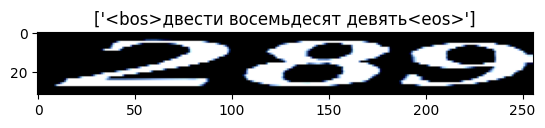

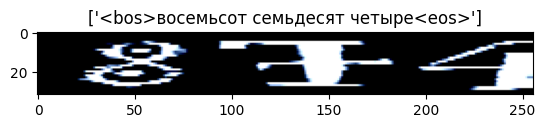

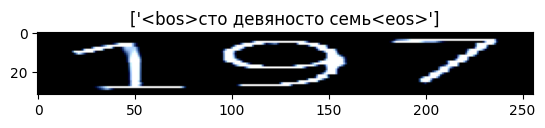

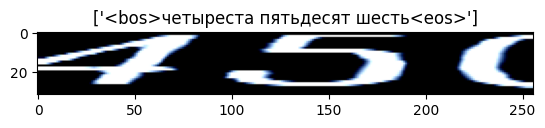

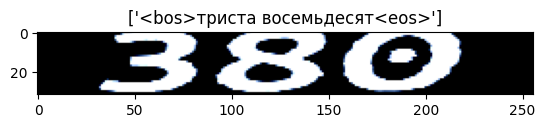

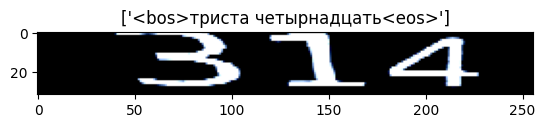

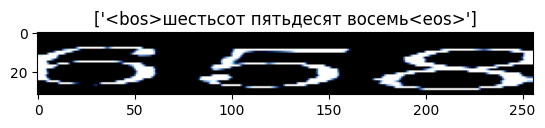

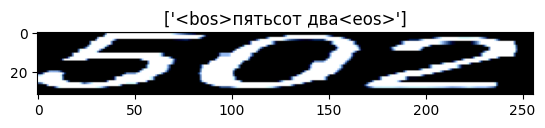

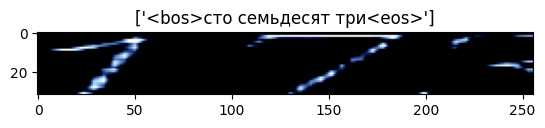

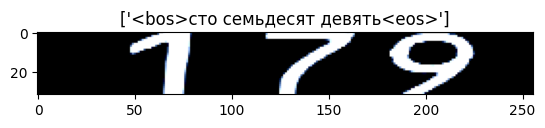

In [199]:
@torch.inference_mode()
def run_inference_kv_cache(model: CaptioningModel, images: torch.Tensor) -> tp.List[str]:
    """
    Оптимизированный autoregressive inference с KV-cache

    Args:
        model: обученная модель CaptioningModel
        images: батч изображений [batch_size, 3, 32, 256]

    Returns:
        captions: список строк-описаний (тот же формат, что и ранее)
    """
    # TODO: Implement KV-cache optimization
    # Hint 1: Forward проходит только ПОСЛЕДНИЙ токен, а не вся последовательность
    # Hint 2: Кэшируйте (K, V) из предыдущих шагов
    # Hint 3: past_key_values растет на каждом шаге: [batch, step, hidden]
    # Hint 4: Ваша реализация должна быть минимум в 1.5x быстрее run_inference_simple
    #    (на время декодирования без времени подсчета эмбеддингов изображения)

    model.eval()

    bos_id = ds_test._bos_id
    eos_id = ds_test._eos_id
    id_to_tok = ds_test._alphabet

    batch_size = images.shape[0]

    # начинаем с <bos>
    seq = torch.full(
        (batch_size, 1),
        bos_id,
        dtype=torch.long,
        device=device
    )

    image_embeds = model._vision_model(images)
    image_embeds = model._rotary(image_embeds, start_index=0)

    # буду трекать, какие еще не выдали eos, и только их гнать через трансформер
    alive = torch.arange(batch_size, device=device)
    kv_cache = None

    for _ in range(MAX_TARGET_SIZE - 1):
        x = seq[alive, -1:]
        x = model._embeddings(x)
        x = model._in_linear(x)
        x = model._rotary(x, start_index=seq.shape[1] - 1)

        x, kv_cache = model._generative_model(x,
                                              memory=image_embeds[alive],
                                              past_kv_cache=kv_cache,
                                              kv_cache_mode=True)

        logits = model._out_linear(x)

        # нам нужен только последний предсказанный токен
        next_token = logits[:, -1].argmax(-1)

        next_token_full = torch.full(
            (batch_size,),
            eos_id,
            dtype=torch.long,
            device=device
        )

        next_token_full[alive] = next_token

        finished = next_token == eos_id

        seq = torch.cat([seq, next_token_full[:, None]], dim=1)

        if finished.all():
            break

        alive = alive[~finished]

        kv_cache = [
            (k[~finished], v[~finished])
            for (k, v) in kv_cache
        ]

    # переводим в текст
    captions = []

    seq = seq.cpu().numpy()

    for tokens in seq:
        text = []
        for t in tokens:
            text.append(id_to_tok[t])
            if t == eos_id:
                break

        captions.append("".join(text))

    return captions

for i in range(10):
    index = random.randint(0, len(ds_test))
    (image, _), _ = ds_train[index]


    result = run_inference_kv_cache(model, image[None, :, :, :].to(device))

    plt.title(result)
    plt.imshow(image.cpu().detach().numpy().transpose(1, 2, 0))
    plt.show()

In [200]:
(batch_images, _), _ = next(iter(loader_test))
print(f"Размер батча: {batch_images.shape[0]}")

benchmark_inference(model, batch_images, run_inference_kv_cache, n_runs=10)
None

Размер батча: 1024


inference runtime: 100%|██████████| 10/10 [00:02<00:00,  4.87it/s]


Average inference time: 0.2045 sec


In [201]:
(batch_images, _), _ = next(iter(loader_test))
print(f"Размер батча: {batch_images.shape[0]}")

print("Inference simple")
benchmark_inference(model, batch_images, run_inference_simple, n_runs=10)
print("Inference without kl_cache")
benchmark_inference(model, batch_images, run_inference, n_runs=10)
print("Inference with kl_cache")
benchmark_inference(model, batch_images, run_inference_kv_cache, n_runs=10)
None

Размер батча: 1024
Inference simple


inference runtime: 100%|██████████| 10/10 [00:07<00:00,  1.39it/s]



Average inference time: 0.7180 sec
Inference without kl_cache


inference runtime: 100%|██████████| 10/10 [00:04<00:00,  2.11it/s]



Average inference time: 0.4720 sec
Inference with kl_cache


inference runtime: 100%|██████████| 10/10 [00:02<00:00,  4.92it/s]


Average inference time: 0.2025 sec


Ну это быстрее, классно. Но эта домашка не стоила полтора дня...